In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

import plotly.express as px
import plotly.graph_objects as go

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

TURBINES = {
    'NREL 5MW':     {'file': 'NREL_Reference_5MW_126 (1).csv', 'P_nom_kw': 5000,  'D': 126},
    'DTU 10MW':     {'file': 'DTU_Reference_v1_10MW_178.csv',  'P_nom_kw': 10000, 'D': 178},
    'LEANWIND 8MW': {'file': 'LEANWIND_Reference_8MW_164.csv', 'P_nom_kw': 8000,  'D': 164},
    'IEA 3.4MW':    {'file': 'IEA_Reference_3.4MW_130.csv',    'P_nom_kw': 3400,  'D': 130},
    'IEA 10MW':     {'file': 'IEA_Reference_10MW_198.csv',     'P_nom_kw': 10000, 'D': 198},
    'IEA 15MW':     {'file': 'IEA_Reference_15MW_240.csv',     'P_nom_kw': 15000, 'D': 240},
}

## Curvas de Potência — Turbinas de Referência

Comparação entre NREL 5MW, DTU 10MW, LEANWIND 8MW, IEA 3.4/10/15MW usando dados públicos de curvas de potência.

In [2]:
dfs = {}

for name, info in TURBINES.items():
    df = pd.read_csv(info['file'])
    # Limpar colunas extras vazias (ex: IEA 15MW)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    
    print(f"\n{'='*50}")
    print(f"{name} — {info['file']}")
    print(f"  Shape: {df.shape}")
    print(f"  Colunas: {list(df.columns)}")
    print(f"  Wind Speed range: {df['Wind Speed [m/s]'].min():.1f} – {df['Wind Speed [m/s]'].max():.1f} m/s")
    print(f"  Power range: {df['Power [kW]'].min():.1f} – {df['Power [kW]'].max():.1f} kW")
    print(df.head())
    
    dfs[name] = df


NREL 5MW — NREL_Reference_5MW_126 (1).csv
  Shape: (50, 5)
  Colunas: ['Wind Speed [m/s]', 'Power [kW]', 'Cp [-]', 'Thrust [kN]', 'Ct [-]']
  Wind Speed range: 3.0 – 25.0 m/s
  Power range: 40.5 – 5000.9 kW
   Wind Speed [m/s]  Power [kW]    Cp [-]  Thrust [kN]    Ct [-]
0               3.0       40.52  0.208547        77.66  1.132035
1               4.0      177.67  0.385795       121.90  0.999471
2               5.0      403.90  0.449038       174.88  0.917697
3               6.0      737.59  0.474547       236.23  0.860850
4               7.0     1187.18  0.480994       304.55  0.815371

DTU 10MW — DTU_Reference_v1_10MW_178.csv
  Shape: (22, 5)
  Colunas: ['Wind Speed [m/s]', 'Power [kW]', 'Cp [-]', 'Thrust [kN]', 'Ct [-]']
  Wind Speed range: 4.0 – 25.0 m/s
  Power range: 280.2 – 10683.7 kW
   Wind Speed [m/s]  Power [kW]  Cp [-]  Thrust [kN]  Ct [-]
0                 4       280.2   0.286        225.9   0.923
1                 5       799.1   0.418        351.5   0.919
2         

In [3]:
frames = []

for name, info in TURBINES.items():
    df = dfs[name].copy()
    df = df.rename(columns={
        'Wind Speed [m/s]': 'wind_speed_ms',
        'Power [kW]': 'power_kw',
        'Cp [-]': 'cp',
        'Thrust [kN]': 'thrust_kn',
        'Ct [-]': 'ct',
    })
    df['turbine'] = name
    df['P_nom_kw'] = info['P_nom_kw']
    df['D'] = info['D']
    df['power_norm'] = df['power_kw'] / info['P_nom_kw']
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
print(f"Shape consolidado: {df_all.shape}")
print(f"Turbinas: {df_all['turbine'].unique()}")
df_all.head()

Shape consolidado: (244, 9)
Turbinas: ['NREL 5MW' 'DTU 10MW' 'LEANWIND 8MW' 'IEA 3.4MW' 'IEA 10MW' 'IEA 15MW']


,wind_speed_ms,power_kw,cp,thrust_kn,ct,turbine,P_nom_kw,D,power_norm
0,3.0,40.52,0.208547,77.66,1.132035,NREL 5MW,5000,126,0.008104
1,4.0,177.67,0.385795,121.90,0.999471,NREL 5MW,5000,126,0.035534
2,5.0,403.90,0.449038,174.88,0.917697,NREL 5MW,5000,126,0.080780
3,6.0,737.59,0.474547,236.23,0.860850,NREL 5MW,5000,126,0.147518
4,7.0,1187.18,0.480994,304.55,0.815371,NREL 5MW,5000,126,0.237436


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNÇÕES DE VISUALIZAÇÃO — Reutilizáveis em todo o notebook
# ═══════════════════════════════════════════════════════════════════════════

def plot_power_curves(df, turbines_list, mode='both', ax=None):
    """Plota curvas de potência absoluta e/ou normalizada para a lista de turbinas."""
    df_plot = df[df['turbine'].isin(turbines_list)].sort_values(['turbine', 'wind_speed_ms']).copy()

    if mode not in {'both', 'absolute', 'normalized'}:
        raise ValueError("mode deve ser 'both', 'absolute' ou 'normalized'")

    if mode == 'both':
        if ax is None:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
        else:
            axes = ax
            fig = None

        for name in turbines_list:
            df_t = df_plot[df_plot['turbine'] == name]
            axes[0].plot(df_t['wind_speed_ms'], df_t['power_kw'], marker='o', linewidth=1.8, markersize=3, label=name)
            axes[1].plot(df_t['wind_speed_ms'], df_t['power_norm'], marker='o', linewidth=1.8, markersize=3, label=name)

        axes[0].set_title('Curvas de Potência Absoluta')
        axes[0].set_xlabel('Velocidade do Vento (m/s)')
        axes[0].set_ylabel('Potência (kW)')
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title('Curvas de Potência Normalizada (P/P_nom)')
        axes[1].set_xlabel('Velocidade do Vento (m/s)')
        axes[1].set_ylabel('Potência Normalizada')
        axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim(-0.05, 1.15)

        axes[0].legend(fontsize=8)
        axes[1].legend(fontsize=8)

        if fig is not None:
            fig.suptitle('Comparação de Curvas de Potência', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

    elif mode == 'absolute':
        if ax is None:
            _, axis = plt.subplots(figsize=(10, 6))
        else:
            axis = ax

        for name in turbines_list:
            df_t = df_plot[df_plot['turbine'] == name]
            axis.plot(df_t['wind_speed_ms'], df_t['power_kw'], marker='o', linewidth=1.8, markersize=3, label=name)

        axis.set_title('Curvas de Potência Absoluta')
        axis.set_xlabel('Velocidade do Vento (m/s)')
        axis.set_ylabel('Potência (kW)')
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=8)

        if ax is None:
            plt.tight_layout()
            plt.show()

    else:  # normalized
        if ax is None:
            _, axis = plt.subplots(figsize=(10, 6))
        else:
            axis = ax

        for name in turbines_list:
            df_t = df_plot[df_plot['turbine'] == name]
            axis.plot(df_t['wind_speed_ms'], df_t['power_norm'], marker='o', linewidth=1.8, markersize=3, label=name)

        axis.set_title('Curvas de Potência Normalizada (P/P_nom)')
        axis.set_xlabel('Velocidade do Vento (m/s)')
        axis.set_ylabel('Potência Normalizada')
        axis.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
        axis.set_ylim(-0.05, 1.15)
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=8)

        if ax is None:
            plt.tight_layout()
            plt.show()


def plot_3d_scatter(df, turbines_list):
    """Scatter 3D: wind_speed × turbine × power_kw para turbinas selecionadas."""
    df_3d = df[df['turbine'].isin(turbines_list)].copy()
    palette = px.colors.qualitative.Plotly
    fig_3d = go.Figure()

    for i, name in enumerate(turbines_list):
        df_t = df_3d[df_3d['turbine'] == name].copy()
        custom = np.column_stack([
            df_t['power_norm'].values,
            df_t['cp'].values,
            df_t['ct'].values,
            df_t['thrust_kn'].values,
        ])
        fig_3d.add_trace(
            go.Scatter3d(
                x=df_t['wind_speed_ms'],
                y=[name] * len(df_t),
                z=df_t['power_kw'],
                mode='markers',
                name=name,
                marker=dict(
                    size=4,
                    symbol='circle',
                    color=palette[i % len(palette)],
                    opacity=0.8,
                ),
                customdata=custom,
                hovertemplate=(
                    '<b>%{y}</b><br>'
                    'Wind Speed: %{x:.2f} m/s<br>'
                    'Power: %{z:.1f} kW<br>'
                    'P/P_nom: %{customdata[0]:.3f}<br>'
                    'Cp: %{customdata[1]:.3f}<br>'
                    'Ct: %{customdata[2]:.3f}<br>'
                    'Thrust: %{customdata[3]:.1f} kN<extra></extra>'
                ),
            )
        )

    fig_3d.update_layout(
        title='Potência 3D por Velocidade e Turbina (apenas pontos)',
        scene=dict(
            xaxis_title='Velocidade do Vento (m/s)',
            yaxis_title='Turbina',
            zaxis_title='Potência (kW)',
        ),
        height=700,
        legend_title='Turbina',
    )
    fig_3d.show()


print('Funções reutilizáveis carregadas: plot_power_curves, plot_3d_scatter')

Funções reutilizáveis carregadas: plot_power_curves, plot_3d_scatter


In [5]:
# Redefinição autossuficiente para evitar dependência de ordem de execução

def plot_aep_heatmap(df_turbine, turbine_name, k_range, lam_range):
    """Heatmap AEP Weibull (k × λ) para uma turbina."""
    curve = df_turbine[['wind_speed_ms', 'power_kw']].dropna().sort_values('wind_speed_ms')

    v_data = curve['wind_speed_ms'].values
    p_data = curve['power_kw'].values

    def _weibull_pdf(v, k, lam):
        return (k / lam) * (v / lam) ** (k - 1) * np.exp(-(v / lam) ** k)

    def _calc_aep_local(k, lam):
        v_range = np.arange(0, 30, 0.5)
        p_interp = np.interp(v_range, v_data, p_data, left=0, right=0)
        pdf = _weibull_pdf(v_range, k, lam)
        return np.trapezoid(p_interp * pdf, v_range) * 8760 / 1000

    grid_rows = []
    for k in k_range:
        for lam in lam_range:
            grid_rows.append({'k': k, 'lam': lam, 'AEP_MWh': _calc_aep_local(k, lam)})

    df_aep_grid = pd.DataFrame(grid_rows)
    aep_heatmap = df_aep_grid.pivot(index='k', columns='lam', values='AEP_MWh')

    fig_heat = px.imshow(
        aep_heatmap,
        origin='lower',
        aspect='auto',
        color_continuous_scale='YlOrRd',
        labels={
            'x': 'λ (escala Weibull)',
            'y': 'k (forma Weibull)',
            'color': 'AEP (MWh/ano)',
        },
        title=f'Heatmap de Sensibilidade do AEP — {turbine_name}',
    )
    fig_heat.update_layout(height=600, width=1050)
    fig_heat.show()

    return df_aep_grid

Colunas padronizadas para comparação direta. `power_norm = P / P_nom` permite comparar perfis aerodinâmicos independentemente da escala.

In [6]:
desc = df_all.groupby('turbine')[['wind_speed_ms', 'power_kw', 'cp', 'thrust_kn', 'ct']].describe().T
desc

turbine                  DTU 10MW      IEA 10MW      IEA 15MW    IEA 3.4MW  \
wind_speed_ms count     22.000000     20.000000     59.000000    50.000000   
              mean      14.500000     11.375000      9.487517    11.414974   
              std        6.493587      5.548530      4.217922     6.035131   
              min        4.000000      3.000000      3.000000     3.000000   
              25%        9.250000      7.750000      6.850000     7.316275   
              50%       14.500000     10.750000      9.500000     9.036650   
              75%       19.750000     14.250000     10.789250    15.474200   
              max       25.000000     25.000000     24.999999    25.000000   
power_kw      count     22.000000     20.000000     59.000000    50.000000   
              mean    8190.040909   7587.568500   9263.173215  2279.575255   
              std     3838.926951   4060.971510   5815.114524  1173.317336   
              min      280.200000     37.874000     70.021377    51.620327   
              25%     5805.475000   4330.800250   4063.778442  1406.734820   
              50%    10639.400000  10473.993500  10855.043740  2652.984360   
              75%    10643.200000  10638.300000  14994.531760  3370.000704   
              max    10683.700000  10638.301000  14997.626870  3370.104925   
cp            count     22.000000     20.000000     59.000000    50.000000   
              mean       0.256364      0.316950      0.414734     0.297584   
              std        0.172985      0.168764      0.125865     0.169447   
              min        0.044000      0.037000      0.037062     0.026700   
              25%        0.090750      0.158750      0.418223     0.112900   
              50%        0.230000      0.366000      0.467725     0.411850   
              75%        0.452500      0.478750      0.489070     0.444800   
              max        0.478000      0.487000      0.489383     0.445200   
thrust_kn     count     22.000000     20.000000     59.000000    50.000000   
              mean     781.777273    912.108100   1788.751305   302.790093   
              std      304.894534    387.683101    620.112074   120.596357   
              min      225.900000    155.126000    593.964861    59.159022   
              25%      604.725000    650.360000   1359.102527   214.108081   
              50%      715.450000    898.762500   1618.598616   298.388532   
              75%      948.625000   1241.942000   2502.230472   369.703901   
              max     1507.400000   1504.588000   2782.638159   627.277807   
ct            count     22.000000     20.000000     59.000000    50.000000   
              mean       0.435682      0.560000      0.678768     0.508494   
              std        0.349036      0.327170      0.218170     0.317808   
              min        0.059000      0.049000      0.045815     0.037200   
              25%        0.113250      0.239000      0.671476     0.143375   
              50%        0.291000      0.656000      0.803452     0.766400   
              75%        0.814000      0.876000      0.809261     0.766400   
              max        0.923000      0.926000      0.834932     0.814000   

turbine              LEANWIND 8MW     NREL 5MW  
wind_speed_ms count     43.000000    50.000000  
              mean      14.500000    11.750000  
              std        6.278269     5.165476  
              min        4.000000     3.000000  
              25%        9.250000     7.825000  
              50%       14.500000    10.850000  
              75%       19.750000    12.750000  
              max       25.000000    25.000000  
power_kw      count     43.000000    50.000000  
              mean    6205.116279  3567.388800  
              std     2787.412712  1695.980532  
              min      110.000000    40.520000  
              25%     4512.500000  1658.022500  
              50%     8000.000000  4384.775000  
              75%     8000.000000  5000.007500  
              max

**Informações obtidas:**
- **Envelope operacional:** O min/max de `wind_speed_ms` revela as velocidades de cut-in e cut-out de cada turbina. O max de `power_kw` confirma a potência nominal.
- **Cp máximo:** O valor máximo de Cp indica a eficiência aerodinâmica de pico do rotor. Valores mais próximos do limite de Betz (0.593) indicam melhor design aerodinâmico.
- **Empuxo:** O max de `thrust_kn` é relevante para o dimensionamento estrutural da torre e fundações — turbinas offshore de grande porte geram cargas de empuxo significativamente maiores.

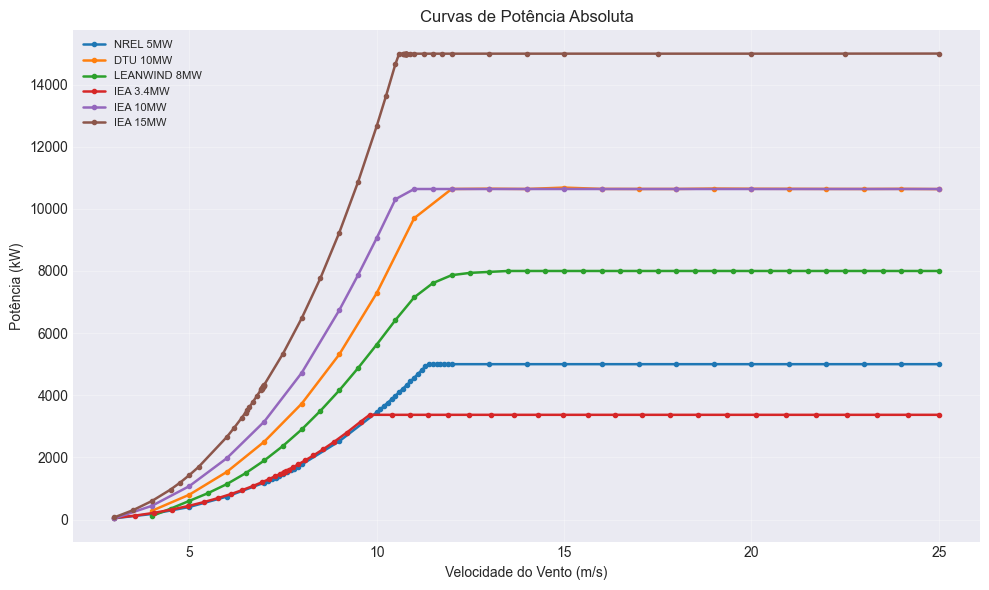

Pontos disponíveis por turbina no scatter 3D:


,n_points
turbine,
NREL 5MW,50
DTU 10MW,22
LEANWIND 8MW,43
IEA 3.4MW,50
IEA 10MW,20
IEA 15MW,59


In [7]:
turbine_names = list(TURBINES.keys())

plot_power_curves(df_all, turbine_names, mode='absolute')

points_per_turbine = (
    df_all[df_all['turbine'].isin(turbine_names)]['turbine']
    .value_counts()
    .reindex(turbine_names)
)
print('Pontos disponíveis por turbina no scatter 3D:')
display(points_per_turbine.rename('n_points').to_frame())

plot_3d_scatter(df_all, turbine_names)

**Informações obtidas:**
- **Formato sigmoidal:** Cada curva apresenta as três regiões características: (1) potência zero abaixo do cut-in, (2) crescimento cúbico (P ∝ v³) e (3) plateau na potência nominal até o cut-out.
- **Transição para potência nominal:** Turbinas offshore de grande porte (IEA 15MW, DTU 10MW) apresentam transições mais suaves, refletindo controle de pitch mais sofisticado.
- **Cut-out:** Todas as turbinas atingem cut-out em 25 m/s — padrão da indústria para proteção estrutural.

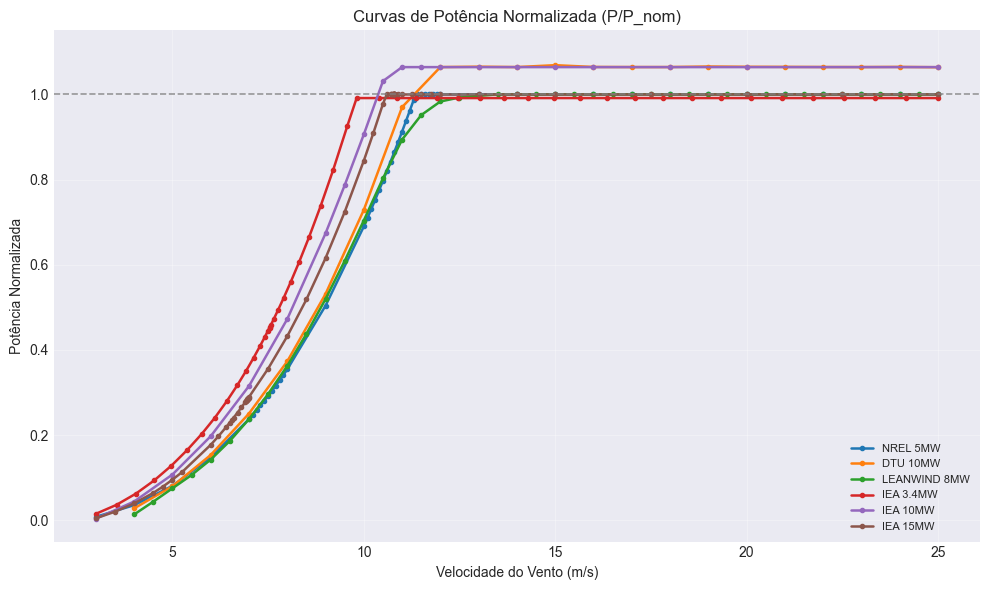

In [8]:
turbine_names = list(TURBINES.keys())

plot_power_curves(df_all, turbine_names, mode='normalized')

df_norm = df_all.sort_values(['turbine', 'wind_speed_ms']).copy()
slope_rows = []
for name in turbine_names:
    df_t = df_norm[df_norm['turbine'] == name].sort_values('wind_speed_ms').copy()
    df_t['dP_dV_norm'] = np.gradient(df_t['power_norm'], df_t['wind_speed_ms'])
    slope_rows.append(df_t[['turbine', 'wind_speed_ms', 'dP_dV_norm']])

df_slope = pd.concat(slope_rows, ignore_index=True)

fig_slope = px.line(
    df_slope,
    x='wind_speed_ms',
    y='dP_dV_norm',
    color='turbine',
    title='Sensibilidade da Curva Normalizada (d(P/P_nom)/dV)',
    labels={
        'wind_speed_ms': 'Velocidade do Vento (m/s)',
        'dP_dV_norm': 'Inclinação Normalizada',
        'turbine': 'Turbina',
    },
)
fig_slope.add_hline(y=0, line_dash='dot', line_color='black', opacity=0.7)
fig_slope.update_layout(height=550, width=1050)
fig_slope.show()

**Informações obtidas:**
- **Comparação aerodinâmica:** A normalização elimina o efeito da escala de potência, revelando diferenças no design aerodinâmico entre turbinas.
- **Inclinação na região cúbica:** Turbinas com curvas mais "íngremes" na transição atingem potência nominal em ventos mais baixos — melhor aproveitamento em sítios de vento moderado.
- **Diferenças de cut-in:** Turbinas com cut-in mais baixo (ex: IEA 3.4MW) começam a gerar em ventos mais fracos, capturando mais energia em regimes de vento ameno.
- **Projeto onshore vs offshore:** Turbinas offshore (IEA 15MW, DTU 10MW) são otimizadas para ventos mais fortes e constantes, enquanto modelos onshore priorizam ventos moderados.

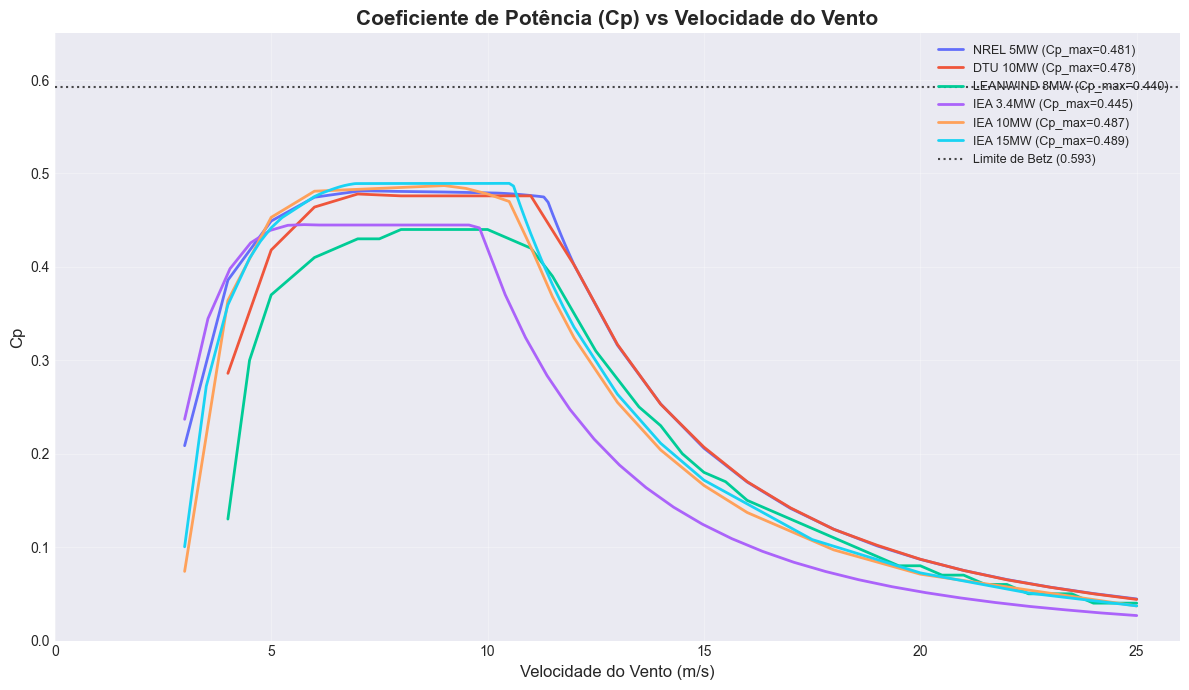

In [9]:
colors = px.colors.qualitative.Plotly

fig, ax = plt.subplots(figsize=(12, 7))

for (name, info), color in zip(TURBINES.items(), colors):
    df_t = df_all[df_all['turbine'] == name].sort_values('wind_speed_ms')
    ax.plot(df_t['wind_speed_ms'], df_t['cp'],
            linewidth=2, color=color, label=f'{name} (Cp_max={df_t["cp"].max():.3f})')

ax.axhline(y=16/27, color='black', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Limite de Betz ({16/27:.3f})')
ax.set_title('Coeficiente de Potência (Cp) vs Velocidade do Vento', fontsize=15, fontweight='bold')
ax.set_xlabel('Velocidade do Vento (m/s)', fontsize=12)
ax.set_ylabel('Cp', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 26)
ax.set_ylim(0, 0.65)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **Cp máximo e limite de Betz:** O limite teórico de Betz (Cp = 16/27 ≈ 0.593) é o máximo que qualquer turbina pode extrair do vento. Turbinas modernas atingem Cp_max entre 0.45 e 0.50.
- **Velocidade do Cp_max:** A velocidade em que o Cp é máximo corresponde à operação ótima do rotor (tip-speed ratio ótimo). Acima dessa velocidade, o pitch é ativado e o Cp cai.
- **Queda do Cp em ventos altos:** Acima da velocidade rated, o controle de pitch reduz deliberadamente o Cp para limitar a potência à nominal — proteção do gerador e drivetrain.
- **Eficiência comparativa:** Turbinas com curvas Cp mais "largas" (plateau mais extenso) capturam energia de forma eficiente em uma faixa maior de velocidades de vento.

,Turbina,P_nominal (MW),Diâmetro (m),Área (m²),Densidade (W/m²)
0,IEA 3.4MW,3.4,130,13273.2,256.2
1,IEA 10MW,10.0,198,30790.7,324.8
2,IEA 15MW,15.0,240,45238.9,331.6
3,LEANWIND 8MW,8.0,164,21124.1,378.7
4,NREL 5MW,5.0,126,12469.0,401.0
5,DTU 10MW,10.0,178,24884.6,401.9


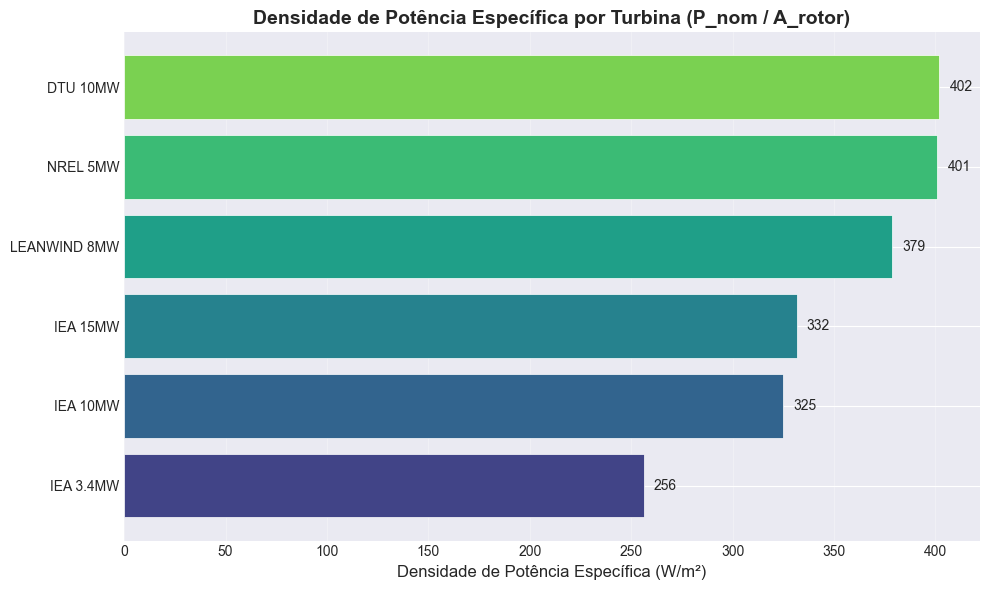

In [10]:
density_data = []
for name, info in TURBINES.items():
    area = np.pi * (info['D'] / 2) ** 2
    sp_density = (info['P_nom_kw'] * 1000) / area  # W/m²
    density_data.append({
        'Turbina': name,
        'P_nominal (MW)': info['P_nom_kw'] / 1000,
        'Diâmetro (m)': info['D'],
        'Área (m²)': round(area, 1),
        'Densidade (W/m²)': round(sp_density, 1),
    })

df_density = pd.DataFrame(density_data).sort_values('Densidade (W/m²)')
display(df_density.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_density['Turbina'], df_density['Densidade (W/m²)'],
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(df_density))),
               edgecolor='white', linewidth=0.5)
ax.set_xlabel('Densidade de Potência Específica (W/m²)', fontsize=12)
ax.set_title('Densidade de Potência Específica por Turbina (P_nom / A_rotor)', fontsize=14, fontweight='bold')

for bar, val in zip(bars, df_density['Densidade (W/m²)']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **Densidade de potência específica (W/m²):** Indica quanto de potência é extraída por unidade de área varrida pelo rotor. Valores mais altos significam que a turbina precisa de ventos mais fortes para operar eficientemente.
- **Tendência da indústria:** Turbinas modernas de grande porte tendem a ter densidades menores (rotores cada vez maiores relativos à potência nominal), otimizadas para capturar mais energia em ventos moderados.
- **Onshore vs offshore:** Turbinas offshore (projetadas para ventos fortes e constantes) geralmente apresentam densidades mais altas. Turbinas onshore de baixa densidade são ideais para sítios de vento fraco.
- **Planejamento de parques:** Este parâmetro influencia o espaçamento entre turbinas — densidades maiores exigem maior distância para minimizar o efeito esteira.

,Turbina,V_cut-in (m/s),V_rated (m/s),V_cut-out (m/s)
0,NREL 5MW,3.0,11.2,25.0
1,DTU 10MW,4.0,11.0,25.0
2,LEANWIND 8MW,4.0,11.5,25.0
3,IEA 3.4MW,3.0,9.8,25.0
4,IEA 10MW,3.0,10.5,25.0
5,IEA 15MW,3.0,10.5,25.0


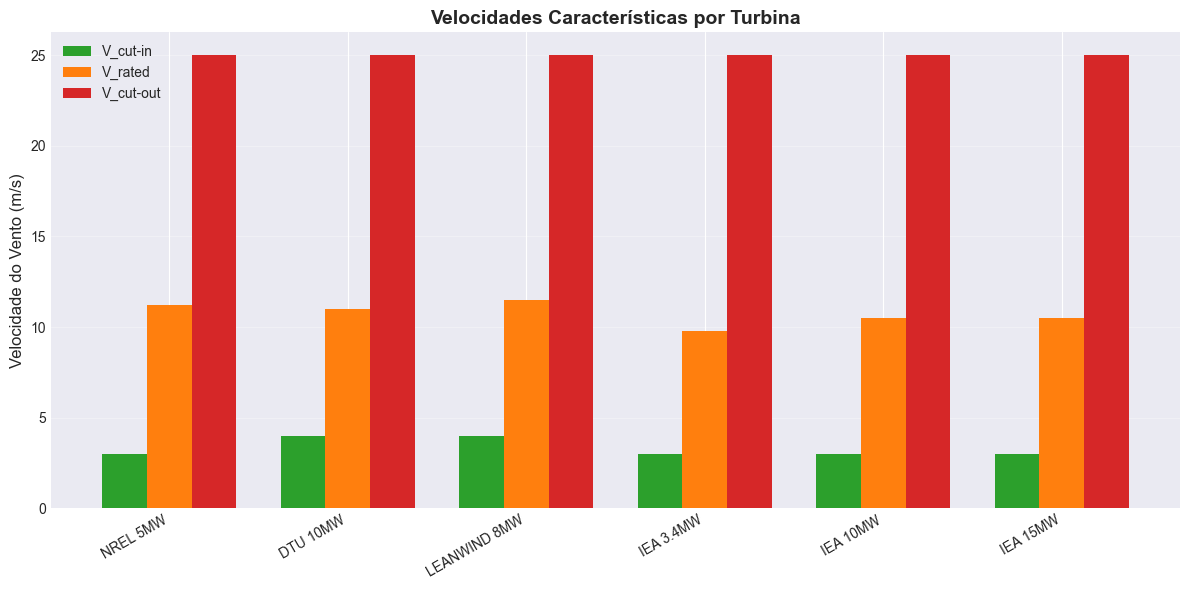

In [11]:
vel_data = []
for name, info in TURBINES.items():
    df_t = df_all[df_all['turbine'] == name].sort_values('wind_speed_ms')
    v_ci = df_t['wind_speed_ms'].min()
    v_co = df_t['wind_speed_ms'].max()
    # Rated speed: primeira velocidade onde potência atinge 95% da nominal
    rated_mask = df_t['power_kw'] >= 0.95 * info['P_nom_kw']
    v_r = df_t.loc[rated_mask, 'wind_speed_ms'].min() if rated_mask.any() else np.nan
    vel_data.append({
        'Turbina': name,
        'V_cut-in (m/s)': round(v_ci, 1),
        'V_rated (m/s)': round(v_r, 1),
        'V_cut-out (m/s)': round(v_co, 1),
    })

df_vel = pd.DataFrame(vel_data)
display(df_vel)

x = np.arange(len(df_vel))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, df_vel['V_cut-in (m/s)'], width, label='V_cut-in', color='#2ca02c')
ax.bar(x, df_vel['V_rated (m/s)'], width, label='V_rated', color='#ff7f0e')
ax.bar(x + width, df_vel['V_cut-out (m/s)'], width, label='V_cut-out', color='#d62728')

ax.set_xticks(x)
ax.set_xticklabels(df_vel['Turbina'], rotation=30, ha='right')
ax.set_ylabel('Velocidade do Vento (m/s)', fontsize=12)
ax.set_title('Velocidades Características por Turbina', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **V_cut-in:** Velocidade mínima para iniciar geração. Valores mais baixos significam que a turbina captura energia em ventos mais fracos — vantajoso em sítios onshore com vento moderado.
- **V_rated:** Velocidade a partir da qual a turbina atinge potência nominal. Turbinas com V_rated baixo e rotores grandes (baixa densidade de potência) maximizam a geração em regimes de vento médio.
- **V_cut-out:** Velocidade máxima de operação, acima da qual a turbina para por segurança estrutural. O padrão industrial é 25 m/s, mas turbinas modernas implementam "soft cut-out" com redução gradual de potência.
- **Envelope operacional:** A diferença entre V_rated e V_cut-in define a "largura" da região de operação parcial — quanto maior, mais aproveitamento em ventos variados.

Cenário,"Offshore (k=2, λ=8)","Onshore (k=2, λ=6)"
Turbina,,
DTU 10MW,31691.9,16413.0
IEA 10MW,36473.0,20177.8
IEA 15MW,50620.0,27697.4
IEA 3.4MW,12931.3,7562.8
LEANWIND 8MW,23892.3,12344.8
NREL 5MW,15104.2,7942.3


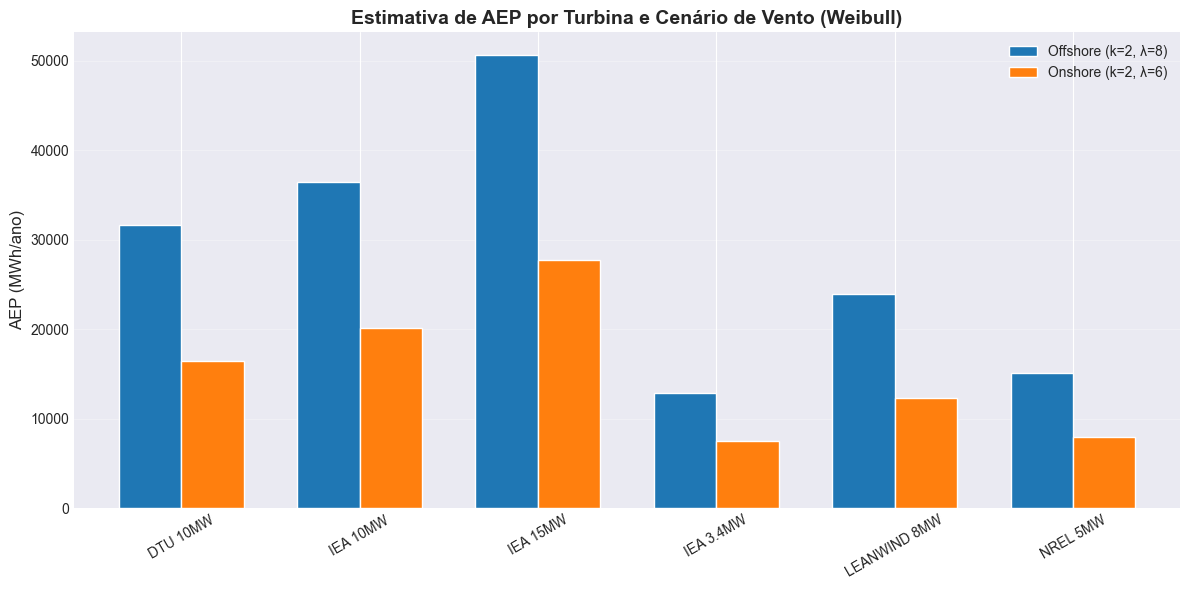

In [12]:
from scipy.interpolate import interp1d

def weibull_pdf(v, k, lam):
    """PDF da distribuição de Weibull: f(v) = (k/lam) * (v/lam)^(k-1) * exp(-(v/lam)^k)"""
    return (k / lam) * (v / lam) ** (k - 1) * np.exp(-(v / lam) ** k)

def calc_aep(df_t, k, lam):
    """
    Calcula AEP (MWh/ano) integrando P(v) * f(v) * 8760h
    """
    v_range = np.arange(0, 30, 0.5)
    power_interp = interp1d(df_t['wind_speed_ms'], df_t['power_kw'],
                            kind='linear', bounds_error=False, fill_value=0)
    power_at_v = power_interp(v_range)
    pdf_at_v = weibull_pdf(v_range, k, lam)
    aep_kwh = np.trapezoid(power_at_v * pdf_at_v, v_range) * 8760
    return aep_kwh / 1000  # MWh

scenarios = {
    'Offshore (k=2, λ=8)': (2, 8),
    'Onshore (k=2, λ=6)':  (2, 6),
}

aep_results = []
for name in TURBINES:
    df_t = df_all[df_all['turbine'] == name].sort_values('wind_speed_ms')
    for scenario, (k, lam) in scenarios.items():
        aep = calc_aep(df_t, k, lam)
        aep_results.append({'Turbina': name, 'Cenário': scenario, 'AEP (MWh)': round(aep, 1)})

df_aep = pd.DataFrame(aep_results)
df_aep_pivot = df_aep.pivot(index='Turbina', columns='Cenário', values='AEP (MWh)')
display(df_aep_pivot)

fig, ax = plt.subplots(figsize=(12, 6))
df_aep_pivot.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
ax.set_title('Estimativa de AEP por Turbina e Cenário de Vento (Weibull)', fontsize=14, fontweight='bold')
ax.set_ylabel('AEP (MWh/ano)', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **AEP (Annual Energy Production):** A integração numérica da curva de potência ponderada pela PDF de Weibull estima a energia anual produzida em cada cenário de vento. É o indicador mais importante para a viabilidade econômica de um projeto eólico.
- **Cenário offshore vs onshore:** A diferença de AEP entre os cenários reflete como cada turbina responde a regimes de vento distintos. Turbinas de grande porte beneficiam-se mais do cenário offshore (λ=8 m/s) com ventos mais fortes.
- **Fator de capacidade implícito:** O fator de capacidade pode ser calculado como FC = AEP / (P_nom × 8760h). Turbinas com FC > 40% em offshore indicam excelente adequação ao recurso eólico do sítio.
- **Seleção de turbina:** Turbinas com maior AEP para o cenário de vento específico do projeto são as melhores candidatas — este cálculo é a base para estudos de viabilidade.

In [13]:
target_turbine = 'IEA 15MW'
df_target = df_all[df_all['turbine'] == target_turbine].sort_values('wind_speed_ms').copy()

k_values = np.round(np.arange(1.5, 3.05, 0.1), 2)
lam_values = np.round(np.arange(5.0, 10.25, 0.25), 2)

df_aep_grid = plot_aep_heatmap(
    df_turbine=df_target,
    turbine_name=target_turbine,
    k_range=k_values,
    lam_range=lam_values,
)

best = df_aep_grid.loc[df_aep_grid['AEP_MWh'].idxmax()]
print(
    f"Maior AEP no grid: {best['AEP_MWh']:.1f} MWh/ano "
    f"(k={best['k']:.2f}, λ={best['lam']:.2f})"
 )

Maior AEP no grid: 76690.8 MWh/ano (k=3.00, λ=10.00)


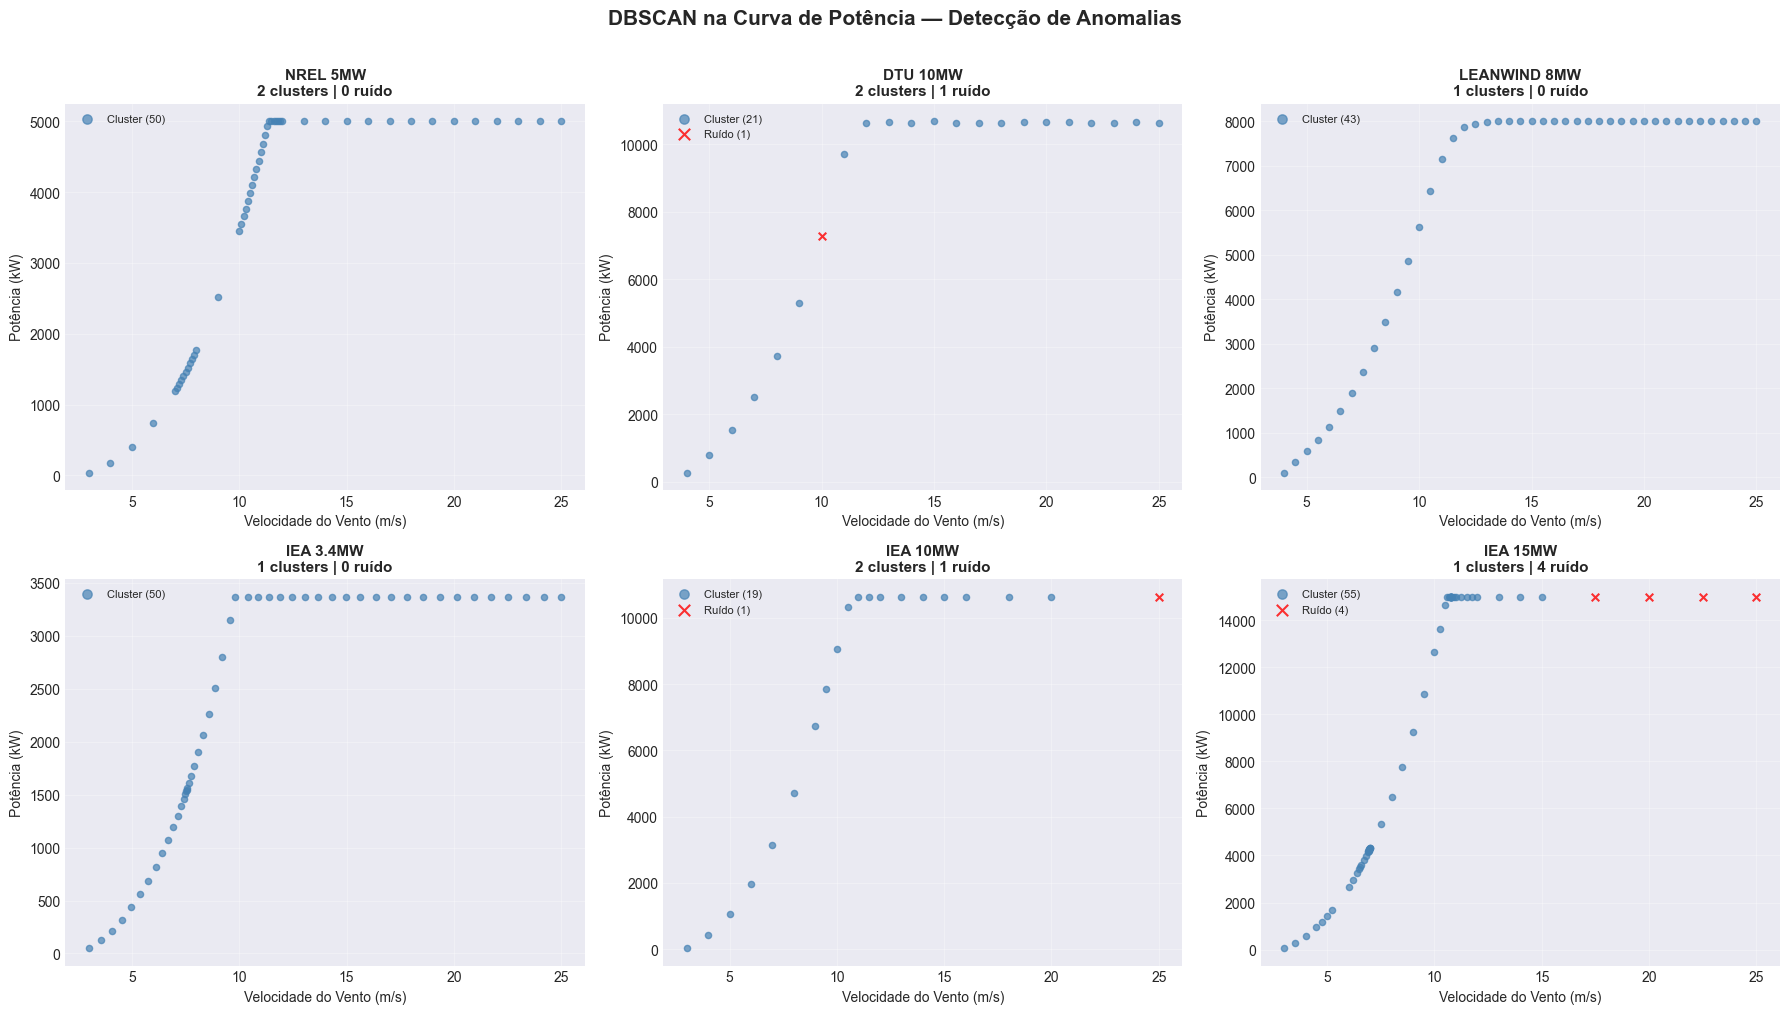

In [14]:
turbine_names = list(TURBINES.keys())
n_cols_grid = 3
n_rows_grid = int(np.ceil(len(turbine_names) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 5 * n_rows_grid))
axes = axes.flatten()

for i, name in enumerate(turbine_names):
    ax = axes[i]
    df_t = df_all[df_all['turbine'] == name][['wind_speed_ms', 'power_kw']].dropna()

    scaler = StandardScaler()
    X = scaler.fit_transform(df_t[['wind_speed_ms', 'power_kw']])

    db = DBSCAN(eps=0.5, min_samples=3)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    mask_clean = (labels != -1)
    mask_noise = (labels == -1)

    if mask_clean.sum() > 0:
        ax.scatter(df_t.loc[mask_clean.astype(bool), 'wind_speed_ms'],
                   df_t.loc[mask_clean.astype(bool), 'power_kw'],
                   s=20, c='steelblue', alpha=0.7, label=f'Cluster ({mask_clean.sum()})')
    if mask_noise.sum() > 0:
        ax.scatter(df_t.loc[mask_noise.astype(bool), 'wind_speed_ms'],
                   df_t.loc[mask_noise.astype(bool), 'power_kw'],
                   s=30, c='red', marker='x', alpha=0.8, label=f'Ruído ({n_noise})')

    ax.set_title(f'{name}\n{n_clusters} clusters | {n_noise} ruído', fontsize=11, fontweight='bold')
    ax.set_xlabel('Velocidade do Vento (m/s)')
    ax.set_ylabel('Potência (kW)')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.3)

for j in range(len(turbine_names), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('DBSCAN na Curva de Potência — Detecção de Anomalias', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **Consistência dos dados de referência:** Em dados tabelados de turbinas de referência, o DBSCAN não deveria encontrar pontos de ruído — todos os pontos seguem a curva teórica sem dispersão. A ausência de ruído confirma a consistência dos dados.
- **Comparação com dados reais (SCADA):** Quando aplicado a dados reais de SCADA (como nos notebooks EDP e Kaggle), o DBSCAN detecta outliers significativos — a comparação entre dados de referência (sem ruído) e dados reais (com ruído) ilustra o impacto das condições operacionais reais na curva de potência.
- **Parâmetros:** eps=0.5 e min_samples=3 são adequados para dados tabelados com poucos pontos. Em dados reais com milhares de registros, parâmetros mais restritivos seriam necessários.

In [15]:
summary_rows = []
for name, info in TURBINES.items():
    df_t = df_all[df_all['turbine'] == name].sort_values('wind_speed_ms')
    area = np.pi * (info['D'] / 2) ** 2

    v_ci = df_t['wind_speed_ms'].min()
    v_co = df_t['wind_speed_ms'].max()
    rated_mask = df_t['power_kw'] >= 0.95 * info['P_nom_kw']
    v_r = df_t.loc[rated_mask, 'wind_speed_ms'].min() if rated_mask.any() else np.nan
    cp_max = df_t['cp'].max()
    sp_density = (info['P_nom_kw'] * 1000) / area

    aep_offshore = calc_aep(df_t, k=2, lam=8)
    aep_onshore = calc_aep(df_t, k=2, lam=6)
    fc_offshore = aep_offshore / (info['P_nom_kw'] / 1000 * 8760) * 100

    summary_rows.append({
        'Turbina': name,
        'P_nom (MW)': info['P_nom_kw'] / 1000,
        'Diâmetro (m)': info['D'],
        'V_ci (m/s)': round(v_ci, 1),
        'V_rated (m/s)': round(v_r, 1),
        'V_co (m/s)': round(v_co, 1),
        'Cp_max': round(cp_max, 3),
        'Dens. (W/m²)': round(sp_density, 1),
        'AEP offshore (MWh)': round(aep_offshore, 0),
        'AEP onshore (MWh)': round(aep_onshore, 0),
        'FC offshore (%)': round(fc_offshore, 1),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.style.background_gradient(subset=['Cp_max', 'AEP offshore (MWh)', 'FC offshore (%)'],
                                      cmap='YlGn')

,Turbina,P_nom (MW),Diâmetro (m),V_ci (m/s),V_rated (m/s),V_co (m/s),Cp_max,Dens. (W/m²),AEP offshore (MWh),AEP onshore (MWh),FC offshore (%)
0,NREL 5MW,5.000000,126,3.000000,11.200000,25.000000,0.481000,401.000000,15104.000000,7942.000000,34.500000
1,DTU 10MW,10.000000,178,4.000000,11.000000,25.000000,0.478000,401.900000,31692.000000,16413.000000,36.200000
2,LEANWIND 8MW,8.000000,164,4.000000,11.500000,25.000000,0.440000,378.700000,23892.000000,12345.000000,34.100000
3,IEA 3.4MW,3.400000,130,3.000000,9.800000,25.000000,0.445000,256.200000,12931.000000,7563.000000,43.400000
4,IEA 10MW,10.000000,198,3.000000,10.500000,25.000000,0.487000,324.800000,36473.000000,20178.000000,41.600000
5,IEA 15MW,15.000000,240,3.000000,10.500000,25.000000,0.489000,331.600000,50620.000000,27697.000000,38.500000


**Resumo Comparativo Final**

Esta tabela consolida todos os parâmetros calculados ao longo do notebook para cada turbina de referência.

**Informações obtidas:**
- **Seleção rápida de turbina:** A tabela permite identificar qual turbina é mais adequada para cada tipo de sítio — por exemplo, IEA 3.4MW para onshore com vento moderado, IEA 15MW para offshore com vento forte.
- **Fator de capacidade (FC):** FC = AEP / (P_nom × 8760h). Valores acima de 40% em offshore indicam excelente adequação ao recurso eólico. Turbinas com FC baixo para um dado cenário de vento sugerem que estão superdimensionadas para aquele regime.
- **Trade-offs de design:** Turbinas com alta densidade de potência específica tendem a ter FC menores em ventos moderados (precisam de ventos fortes para operar eficientemente), mas podem ter AEP absoluta maior em sítios de vento forte.
- **Referência para calibração:** Estes valores servem como benchmark para comparar com dados reais de SCADA — desvios significativos entre a curva de referência e o desempenho medido indicam problemas operacionais ou de manutenção.